<a href="https://colab.research.google.com/github/enriquefroes/previsao-brasileirao-2026/blob/main/notebooks/02_simulacao.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from google.colab import drive
    drive.mount('/content/drive')
    BASE = '/content/drive/MyDrive/analise_previsao_brasileirao'
except ImportError:
    BASE = './analise_previsao_brasileirao'

DADOS, GRAF, TAB = (os.path.join(BASE, p) for p in ['dados', 'graficos', 'tabelas'])
for p in (GRAF, TAB):
    os.makedirs(p, exist_ok=True)

def salvar(nome):
    plt.tight_layout()
    plt.savefig(os.path.join(GRAF, nome), dpi=150, bbox_inches='tight')
    plt.show()
    print('Salvo em', os.path.join(GRAF, nome))

def exige(arquivo, notebook):
    if not os.path.exists(os.path.join(DADOS, arquivo)):
        raise FileNotFoundError(f'Rode primeiro o notebook {notebook}')

exige('forca_times.csv', '01_forca_dos_times')
p = pd.read_csv(os.path.join(DADOS, 'partidas_realizadas.csv'), parse_dates=['data'])
r = pd.read_csv(os.path.join(DADOS, 'jogos_restantes.csv'), parse_dates=['data'])
copas = pd.read_csv(os.path.join(DADOS, 'calendario_copas.csv'), parse_dates=['data'])
forca = pd.read_csv(os.path.join(DADOS, 'forca_times.csv'), index_col='time')
par = pd.read_csv(os.path.join(DADOS, 'parametros_modelo.csv'), index_col=0).iloc[:, 0]
times = sorted(forca.index)
idx = {t: i for i, t in enumerate(times)}
n = len(times)
ATK = np.log(forca.loc[times, 'ataque'].values)
DEF = np.log(forca.loc[times, 'defesa'].values)

def tabela_atual():
    pts, vit, gp, gc = (np.zeros(n) for _ in range(4))
    for _, g in p.iterrows():
        a, b, x, z = idx[g['mandante']], idx[g['visitante']], g['gols_mandante'], g['gols_visitante']
        gp[a] += x; gc[a] += z; gp[b] += z; gc[b] += x
        if x > z: pts[a] += 3; vit[a] += 1
        elif x < z: pts[b] += 3; vit[b] += 1
        else: pts[a] += 1; pts[b] += 1
    return pts, vit, gp, gc

def gols_esperados(desgaste=0.0, janela=3):
    """Gols esperados de mandante e visitante em cada jogo restante.
    desgaste: redução no ataque (e aumento nos gols sofridos) de quem tem jogo de copa a até `janela` dias."""
    H = np.array([idx[t] for t in r['mandante']]); A = np.array([idx[t] for t in r['visitante']])
    lh = np.exp(par['intercepto'] + par['mando'] + ATK[H] + DEF[A])
    la = np.exp(par['intercepto'] + ATK[A] + DEF[H])
    if desgaste:
        for k, j in r.iterrows():
            if pd.isna(j['data']):
                continue
            for lado, time in [('m', j['mandante']), ('v', j['visitante'])]:
                c = copas[copas['time'] == time]
                if ((c['data'] - j['data']).abs().dt.days <= janela).any():
                    if lado == 'm': lh[k] *= 1 - desgaste; la[k] *= 1 + desgaste
                    else: la[k] *= 1 - desgaste; lh[k] *= 1 + desgaste
    return H, A, lh, la

def simular(N=20000, desgaste=0.0, semente=42):
    rng = np.random.default_rng(semente)
    H, A, lh, la = gols_esperados(desgaste)
    gh = rng.poisson(lh, (N, len(r))); ga = rng.poisson(la, (N, len(r)))
    pts0, vit0, gp0, gc0 = tabela_atual()
    pts, vit, gp, gc = (np.tile(v, (N, 1)) for v in (pts0, vit0, gp0, gc0))
    for k in range(len(r)):
        h, a, x, z = H[k], A[k], gh[:, k], ga[:, k]
        pts[:, h] += 3 * (x > z) + (x == z); pts[:, a] += 3 * (z > x) + (x == z)
        vit[:, h] += x > z; vit[:, a] += z > x
        gp[:, h] += x; gc[:, h] += z; gp[:, a] += z; gc[:, a] += x
    # critérios: pontos, vitórias, saldo, gols pró e, por fim, sorteio
    chave = pts * 1e9 + vit * 1e6 + (gp - gc + 500) * 1e3 + gp + rng.random((N, n)) * 1e-3
    pos = (-chave).argsort(1).argsort(1) + 1
    return pts, pos, np.sign(gh - ga).astype(np.int8)


N_SIMULACOES = 20000
DESGASTE = 0.0

Mounted at /content/drive


In [2]:
pts, pos, resultados = simular(N_SIMULACOES, DESGASTE)
np.savez_compressed(os.path.join(DADOS, 'simulacoes.npz'), pts=pts.astype(np.int16), pos=pos.astype(np.int8), resultados=resultados)

pts0 = tabela_atual()[0]
prev = pd.DataFrame({
    'pontos_hoje': pts0.astype(int),
    'pontos_previstos': pts.mean(0),
    'pontos_min_80': np.percentile(pts, 10, axis=0), 'pontos_max_80': np.percentile(pts, 90, axis=0),
    'titulo': (pos == 1).mean(0) * 100, 'top4': (pos <= 4).mean(0) * 100,
    'top6': (pos <= 6).mean(0) * 100, 'z4': (pos >= 17).mean(0) * 100,
    'posicao_media': pos.mean(0)}, index=times).sort_values('pontos_previstos', ascending=False)
prev.index.name = 'time'
prev.round(1).to_csv(os.path.join(TAB, '02_previsao.csv'))
prev.round(1)

,pontos_hoje,pontos_previstos,pontos_min_80,pontos_max_80,titulo,top4,top6,z4,posicao_media
time,,,,,,,,,
Flamengo,60,80.4,76.0,85.0,77.0,100.0,100.0,0.0,1.2
Palmeiras,57,76.7,72.0,82.0,22.8,99.9,100.0,0.0,1.8
Athletico-PR,49,65.5,60.0,71.0,0.1,76.8,96.7,0.0,3.8
Fluminense,48,64.3,59.0,69.0,0.1,62.4,92.7,0.0,4.3
Cruzeiro,45,60.3,55.0,65.0,0.0,26.2,71.2,0.0,5.7
Bahia,46,60.2,55.0,65.0,0.0,21.3,66.2,0.0,5.9
Atlético-MG,43,57.6,53.0,63.0,0.0,10.2,44.4,0.0,6.8
Santos,41,54.6,49.0,60.0,0.0,2.6,18.0,0.0,8.3
Bragantino,36,51.1,46.0,56.0,0.0,0.3,4.8,0.5,10.0


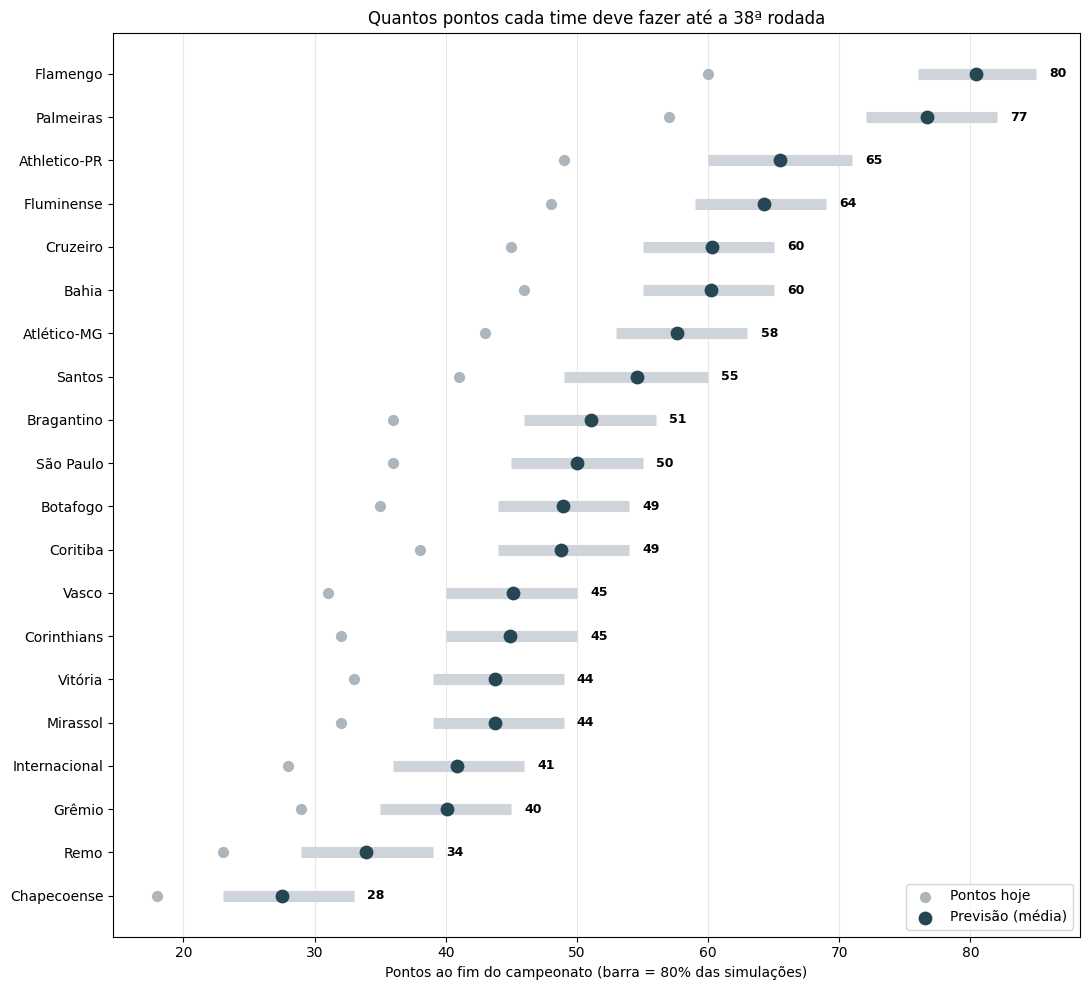

Salvo em /content/drive/MyDrive/analise_previsao_brasileirao/graficos/02a_pontos_previstos.png


In [3]:
t = prev.iloc[::-1]
fig, ax = plt.subplots(figsize=(11, 10))
y = np.arange(len(t))
ax.hlines(y, t['pontos_min_80'], t['pontos_max_80'], color='#ced4da', lw=8)
ax.scatter(t['pontos_hoje'], y, color='#adb5bd', s=50, zorder=3, label='Pontos hoje')
ax.scatter(t['pontos_previstos'], y, color='#264653', s=80, zorder=4, label='Previsão (média)')
for i, (a, b) in enumerate(zip(t['pontos_previstos'], t['pontos_max_80'])):
    ax.text(b + 1, i, f'{a:.0f}', va='center', fontsize=9, fontweight='bold')
ax.set_yticks(y); ax.set_yticklabels(t.index)
ax.set_xlabel('Pontos ao fim do campeonato (barra = 80% das simulações)')
ax.set_title('Quantos pontos cada time deve fazer até a 38ª rodada', fontsize=12)
ax.legend(loc='lower right'); ax.grid(axis='x', alpha=0.3)
salvar('02a_pontos_previstos.png')

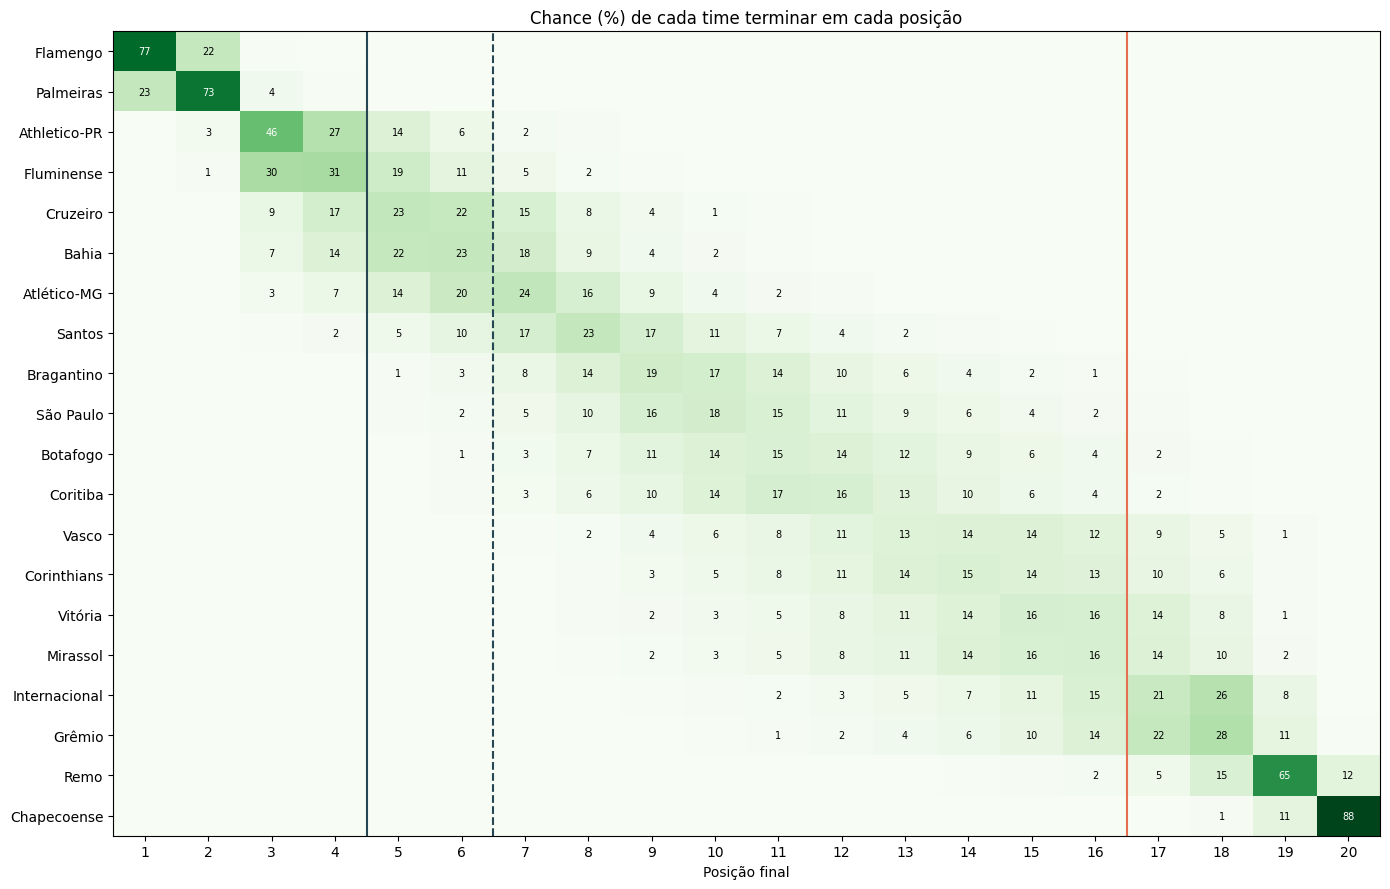

Salvo em /content/drive/MyDrive/analise_previsao_brasileirao/graficos/02b_chance_por_posicao.png


In [4]:
dist = pd.DataFrame([(pos[:, idx[t]][:, None] == np.arange(1, 21)).mean(0) * 100 for t in prev.index], index=prev.index, columns=range(1, 21))
dist.round(1).to_csv(os.path.join(TAB, '02_chance_por_posicao.csv'))
fig, ax = plt.subplots(figsize=(14, 9))
im = ax.imshow(dist.values, cmap='Greens', aspect='auto')
for i in range(len(dist)):
    for j in range(20):
        v = dist.values[i, j]
        if v >= 1:
            ax.text(j, i, f'{v:.0f}', ha='center', va='center', fontsize=7, color='white' if v > 40 else 'black')
ax.set_xticks(range(20)); ax.set_xticklabels(range(1, 21))
ax.set_yticks(range(len(dist))); ax.set_yticklabels(dist.index)
ax.axvline(3.5, color='#264653', lw=1.5); ax.axvline(5.5, color='#264653', lw=1.5, ls='--'); ax.axvline(15.5, color='#e76f51', lw=1.5)
ax.set_xlabel('Posição final'); ax.set_title('Chance (%) de cada time terminar em cada posição', fontsize=12)
salvar('02b_chance_por_posicao.png')

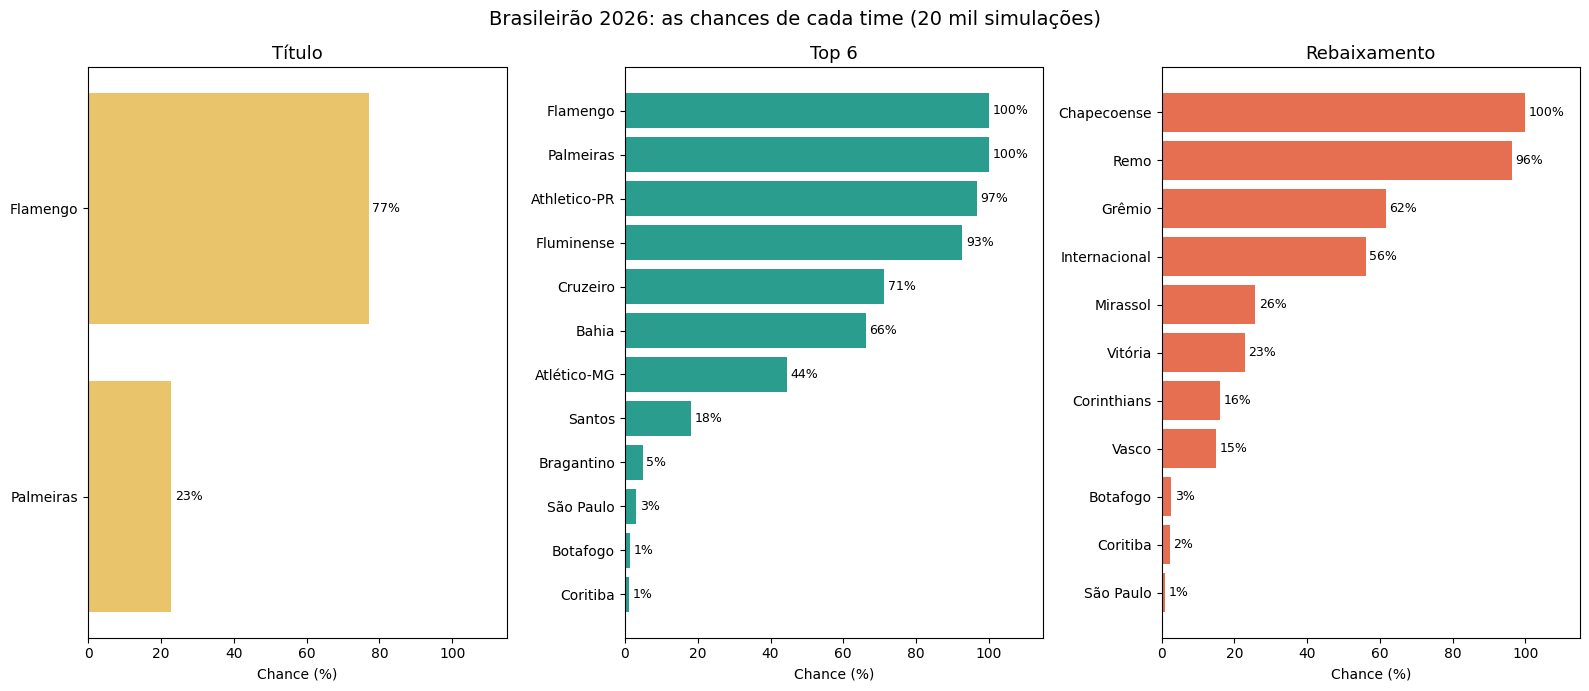

Salvo em /content/drive/MyDrive/analise_previsao_brasileirao/graficos/02c_chances.png


In [5]:
fig, axs = plt.subplots(1, 3, figsize=(16, 7), sharey=False)
for ax, col, titulo, cor in [(axs[0], 'titulo', 'Título', '#e9c46a'), (axs[1], 'top6', 'Top 6', '#2a9d8f'), (axs[2], 'z4', 'Rebaixamento', '#e76f51')]:
    t = prev[prev[col] >= 0.5].sort_values(col)
    ax.barh(t.index, t[col], color=cor)
    for i, v in enumerate(t[col]):
        ax.text(v + 1, i, f'{v:.0f}%' if v >= 1 else '<1%', va='center', fontsize=9)
    ax.set_xlim(0, 115); ax.set_title(titulo, fontsize=13); ax.set_xlabel('Chance (%)')
fig.suptitle('Brasileirão 2026: as chances de cada time (20 mil simulações)', fontsize=14)
salvar('02c_chances.png')

In [6]:
_, pos_d, _ = simular(N_SIMULACOES, desgaste=0.10)
comp = pd.DataFrame({'top6_sem': (pos <= 6).mean(0) * 100, 'top6_com_desgaste': (pos_d <= 6).mean(0) * 100,
                     'z4_sem': (pos >= 17).mean(0) * 100, 'z4_com_desgaste': (pos_d >= 17).mean(0) * 100}, index=times)
afetados = sorted(copas['time'].unique())
comp.loc[afetados].round(1)

,top6_sem,top6_com_desgaste,z4_sem,z4_com_desgaste
Atlético-MG,44.4,35.9,0.0,0.0
Flamengo,100.0,100.0,0.0,0.0
Fluminense,92.7,91.2,0.0,0.0
Grêmio,0.0,0.0,61.6,62.8
Palmeiras,100.0,100.0,0.0,0.0
Vasco,0.1,0.1,14.9,18.4
